# Oxford-IIIT Pet 影像分類
- **Quiz1**：問題定義與資料切分（K-Fold）
- **Quiz2**：Plain CNN vs. Transfer Learning（**不使用資料擴增**，作為 Quiz3 的「擴增前」基準）
- **Quiz3**：資料擴增前後比較、Kernel 視覺化、XAI

輸出：圖片 `Outputs/figures/Q{1,2,3}_*.png`、模型 `Outputs/models/q{1,2,3}_*.pt`、表格 `Outputs/*.csv`

In [ ]:
import sys; sys.path.append("Codes")
import torch, pandas as pd
from PIL import Image
from functools import partial
import Quiz1 as q1, Quiz2 as q2, Quiz3 as q3
q1.set_seed()
print(q2.DEVICE, "| outputs ->", q1.OUT_DIR)

cuda | outputs -> /content/Outputs


# Quiz1 準備資料集

**資料切分**
- 下載 Oxford-IIIT Pet 到 `Data/`；共 7,349 張圖像，涵蓋 37 個貓狗品種，每類約 200 張
- 分類品種皆由檔名推得，所有影像轉成 RGB 後 Resize 成方形並以 ImageNet 平均/標準差正規化。
- 由於找不到官方 `trainval.txt / test.txt`，因此改用**固定SEED的 50/50 分層切分**得到 trainval 與 test；trainval 再由 **Stratified 5-Fold** 切成 train / val。
- test 只在最後評估使用，不參與訓練、挑模型或調參。

100%|██████████| 1.48G/1.48G [01:08<00:00, 23.1MB/s]

Extracting files...


Path to dataset files: /content/Data/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/versions/1
找不到官方 trainval/test.txt，改用 50/50 分層切分（seed 固定）。

【問題定義】
- 任務：影像分類（Image Classification），單標籤多類別（37 類）。
- 輸入：一張 RGB 寵物影像（大小不一、姿勢/背景/光線多變）。
- 輸出：37 個品種的機率分布，取最高者為預測品種（Top-1），並可評估 Top-5。
- 資料類別：12 種貓（如 Abyssinian、Bengal、Persian...）+ 25 種狗
  （如 Beagle、Pug、Shiba Inu...），每類約 200 張，總計約 7,390 張。
- 困難點：細粒度分類（fine-grained），品種間外觀高度相似
  （例如 Staffordshire Bull Terrier vs American Pit Bull Terrier）。
- 資料切分：先分出 trainval 與 test（有官方 trainval/test.txt 就用官方，約各 3,680 / 3,669 張；
  找不到則 50/50 分層切分），trainval 再做 Stratified K-Fold 切成 train/val，
  test 僅用於最終評估，避免資料洩漏。
- 評估指標：Top-1 / Top-5 Accuracy、各類別 ROC 與 Macro-AUC、參數量。

類別數：37  | trainval：3695  | test：3695
貓/狗(trainval)： {'dog': 2495, 'cat': 1200}
saved figure: /content/Outputs/figures/Q1_class_distribution.png


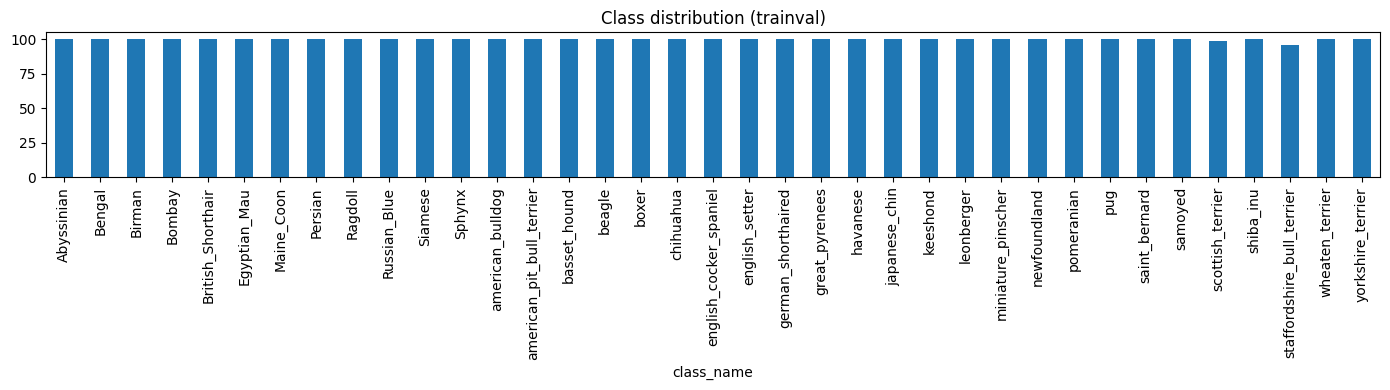

saved figure: /content/Outputs/figures/Q1_samples.png


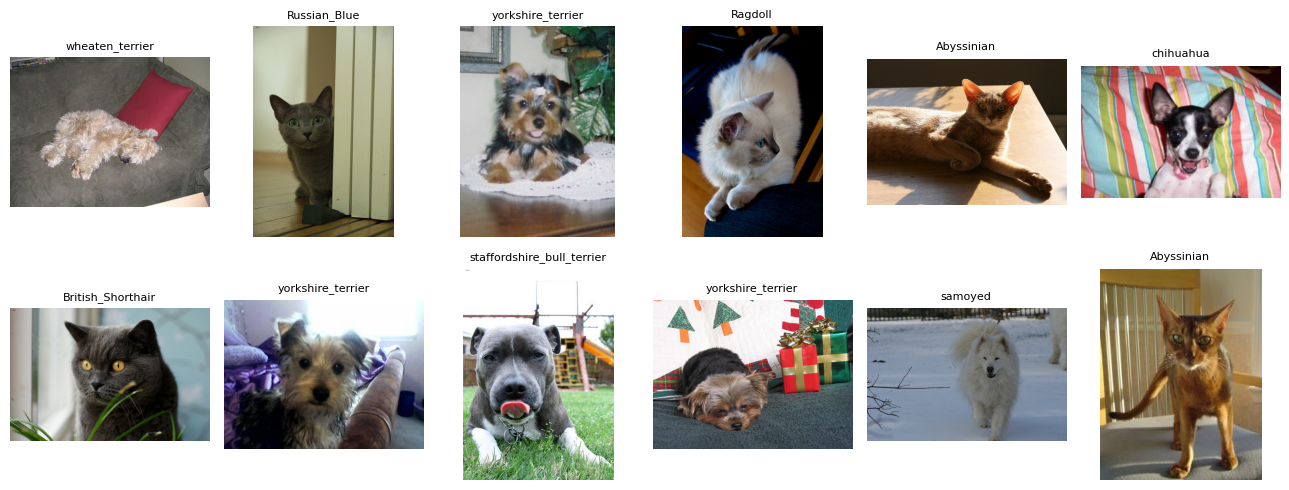

In [ ]:
trainval_df, test_df, class_names = q1.build_dataframes()
q1.summarize(trainval_df, test_df, class_names)     # -> Q1_class_distribution.png
q1.show_samples(trainval_df)                         # -> Q1_samples.png

### Quiz1 小結
- 任務為 **37 類貓狗品種分類**（12 種貓、25 種狗）；其中trainval 共 3,695 張（狗 2,495、貓 1,200），test 共 3,695 張。
- 切分法保持兩邊品種數量相近
- 5 折每折皆為 train 2,956／val 739，類別比例一致（Stratified）。

In [ ]:
N_FOLDS = 5
splits = q1.get_kfold_splits(trainval_df, N_FOLDS)
for k,(tr,va) in enumerate(splits):
    print(f"Fold {k}: train={len(tr)}, val={len(va)}")
FOLD = 0
loaders = partial(q1.make_loaders, trainval_df, test_df, splits, FOLD)

Fold 0: train=2956, val=739
Fold 1: train=2956, val=739
Fold 2: train=2956, val=739
Fold 3: train=2956, val=739
Fold 4: train=2956, val=739


> 後續 Quiz2、Quiz3 的主要訓練皆固定使用 `FOLD = 0`（單次 hold-out）。完整 5 折交叉驗證放在 Quiz2-3 之後，用來檢查結果是否穩定。

# Quiz 2：訓練 CNN 影像分類模型

## Quiz2-1 Plain CNN（自行設計，無資料擴增）

**做法**：自行設計 VGG 風格 Plain CNN —— 4 個 stage（通道 32→64→128→256），每個 stage 為 2×(Conv3×3-BN-ReLU)＋MaxPool，最後 GAP＋Dropout(0.3)＋FC(37)，共 1.18M 參數。輸入 128×128、**不使用資料擴增**；AdamW（lr=2e-3，OneCycle 排程）、batch 64、訓練 30 epochs，並以驗證集 Top-1 最佳的 epoch 還原權重。

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Plain CNN params: (1182725, 1182725)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[01/30] train_loss 3.600 acc 0.050 | val_loss 3.499 top1 0.077 top5 0.269
[02/30] train_loss 3.393 acc 0.089 | val_loss 3.559 top1 0.072 top5 0.277
[03/30] train_loss 3.325 acc 0.099 | val_loss 3.558 top1 0.069 top5 0.290
[04/30] train_loss 3.267 acc 0.102 | val_loss 4.321 top1 0.084 top5 0.231
[05/30] train_loss 3.162 acc 0.139 | val_loss 3.734 top1 0.131 top5 0.373
[06/30] train_loss 3.045 acc 0.161 | val_loss 3.603 top1 0.104 top5 0.425
[07/30] train_loss 2.875 acc 0.189 | val_loss 3.477 top1 0.145 top5 0.413
[08/30] train_loss 2.771 acc 0.202 | val_loss 3.018 top1 0.187 top5 0.507
[09/30] train_loss 2.618 acc 0.252 | val_loss 3.086 top1 0.141 top5 0.495
[10/30] train_loss 2.490 acc 0.281 | val_loss 2.789 top1 0.234 top5 0.591
[11/30] train_loss 2.372 acc 0.307 | val_loss 3.588 top1 0.133 top5 0.438
[12/30] train_loss 2.253 acc 0.336 | val_loss 3.056 top1 0.171 top5 0.552
[13/30] train_loss 2.145 acc 0.363 | val_loss 2.861 top1 0.223 top5 0.602
[14/30] train_loss 2.008 acc 0.399 | v

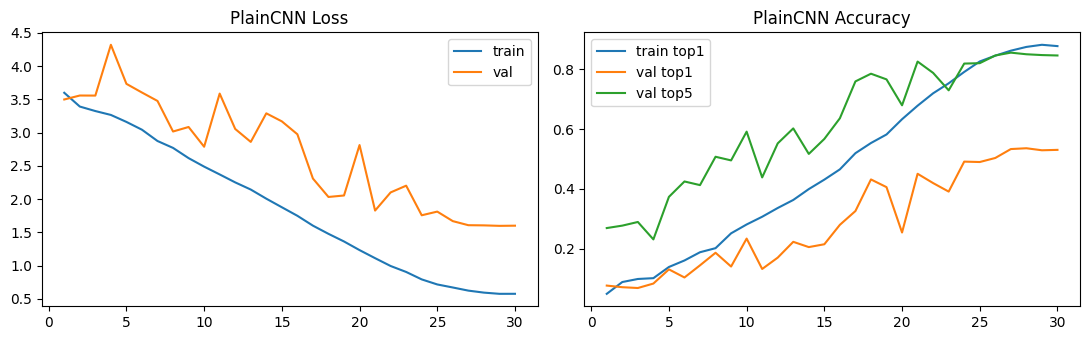

saved model: /content/Outputs/models/q2_plain_cnn.pt


PosixPath('/content/Outputs/models/q2_plain_cnn.pt')

In [ ]:
# 6 min
train_l, val_l, test_l = loaders(img_size=128, batch_size=64, augment="none")
plain = q2.PlainCNN(len(class_names))
print("Plain CNN params:", q2.count_params(plain))
plain, hist_plain, sec_plain = q2.train_model(plain, train_l, val_l, epochs=30, lr=2e-3)
q2.plot_history(hist_plain, "PlainCNN", tag="plain")          # -> Q2_plain_history.png
q1.save_model(plain, "q2_plain_cnn")                           # -> q2_plain_cnn.pt

In [ ]:
pred_plain, m_plain = q2.predict_testset(plain, test_l, test_df, class_names)
pred_plain.to_csv(q1.OUT_DIR/"q2_pred_plain.csv", index=False)
display(pred_plain.head(10))
display(q2.per_class_accuracy(pred_plain).head(10))

Test Top-1: 0.5275 | Top-5: 0.8658


,file,true,pred_top1,confidence,pred_top5,correct_top1,correct_top5
0,wheaten_terrier_107,wheaten_terrier,wheaten_terrier,0.633114,"wheaten_terrier, havanese, scottish_terrier, g...",True,True
1,Russian_Blue_24,Russian_Blue,Russian_Blue,0.525885,"Russian_Blue, British_Shorthair, Bombay, scott...",True,True
2,pug_81,pug,havanese,0.280641,"havanese, great_pyrenees, scottish_terrier, ja...",False,True
3,boxer_144,boxer,basset_hound,0.766254,"basset_hound, beagle, boxer, american_pit_bull...",False,True
4,British_Shorthair_154,British_Shorthair,Russian_Blue,0.698315,"Russian_Blue, British_Shorthair, Sphynx, Bomba...",False,True
5,pug_109,pug,pug,0.786671,"pug, chihuahua, Sphynx, Bengal, american_bulldog",True,True
6,leonberger_127,leonberger,leonberger,0.869223,"leonberger, keeshond, staffordshire_bull_terri...",True,True
7,Siamese_154,Siamese,Siamese,0.281366,"Siamese, Ragdoll, Birman, Sphynx, chihuahua",True,True
8,keeshond_157,keeshond,keeshond,0.945434,"keeshond, havanese, leonberger, scottish_terri...",True,True
9,Ragdoll_224,Ragdoll,Ragdoll,0.431423,"Ragdoll, Persian, shiba_inu, Abyssinian, Maine...",True,True


,correct_top1,correct_top5
true,,
american_pit_bull_terrier,0.200000,0.810000
boxer,0.300000,0.850000
beagle,0.330000,0.930000
chihuahua,0.340000,0.800000
english_cocker_spaniel,0.370000,0.900000
staffordshire_bull_terrier,0.378947,0.610526
english_setter,0.400000,0.770000
basset_hound,0.420000,0.840000
scottish_terrier,0.440000,0.760000


### Plain CNN 小結
- 參數量 1.18M；測試集 **Top-1 = 52.75%、Top-5 = 86.58%**。
- 明顯**過擬合**：最後訓練準確率 87.7%，驗證僅約 53%。前 20 個 epoch 的驗證曲線震盪很大（例如第 10 epoch 為 23.4%、第 11 epoch 掉到 13.3%），後期隨學習率下降才趨穩。
- 最難分辨的品種：american_pit_bull_terrier（Top-1 僅 20%）、boxer（30%）、beagle（33%）、chihuahua（34%）；staffordshire_bull_terrier 的 Top-5 只有 61%，是全體最低。這些多為外觀相近的梗犬／鬥牛犬類，另外灰色短毛貓（British_Shorthair → Russian_Blue）也會互相混淆。

## Quiz2-2 經典 CNN Backbone（ResNet-18 Transfer Learning，無資料擴增）

**做法**：載入 ImageNet 預訓練的 ResNet-18，將 `fc` 換成 Dropout＋Linear(37)，**全網路微調**（共 11.2M 參數）。輸入 224×224、不使用資料擴增；AdamW（lr=1e-3，OneCycle）、batch 64、10 epochs。與 Plain CNN 使用相同資料切分（fold 0）與相同的最佳 epoch 還原規則。

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


ResNet-18 params: (11195493, 11195493)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[01/10] train_loss 2.278 acc 0.470 | val_loss 0.963 top1 0.766 top5 0.966
[02/10] train_loss 0.611 acc 0.842 | val_loss 2.731 top1 0.369 top5 0.778
[03/10] train_loss 0.432 acc 0.876 | val_loss 1.889 top1 0.524 top5 0.853
[04/10] train_loss 0.192 acc 0.950 | val_loss 1.197 top1 0.662 top5 0.931
[05/10] train_loss 0.060 acc 0.988 | val_loss 0.927 top1 0.742 top5 0.968
[06/10] train_loss 0.015 acc 0.999 | val_loss 0.602 top1 0.821 top5 0.984
[07/10] train_loss 0.005 acc 1.000 | val_loss 0.526 top1 0.842 top5 0.982
[08/10] train_loss 0.003 acc 1.000 | val_loss 0.518 top1 0.846 top5 0.984
[09/10] train_loss 0.003 acc 1.000 | val_loss 0.520 top1 0.844 top5 0.984
[10/10] train_loss 0.002 acc 1.000 | val_loss 0.519 top1 0.846 top5 0.982
saved figure: /content/Outputs/figures/Q2_resnet18_history.png


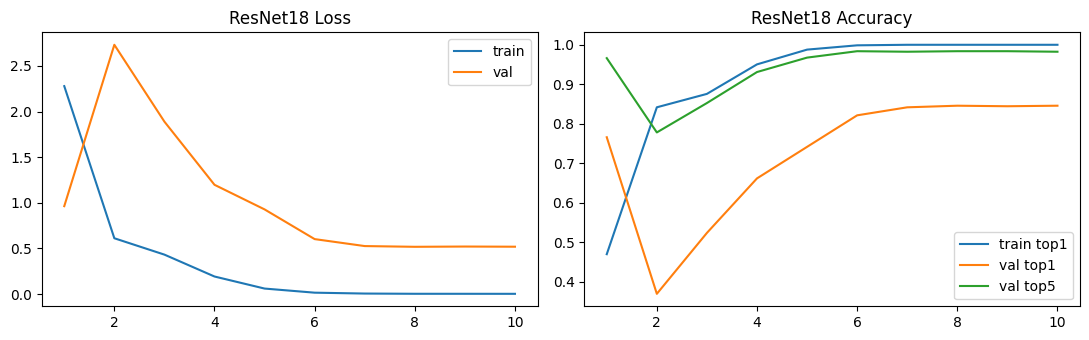

saved model: /content/Outputs/models/q2_resnet18.pt


PosixPath('/content/Outputs/models/q2_resnet18.pt')

In [ ]:
train_b, val_b, test_b = loaders(img_size=224, batch_size=64, augment="none")
resnet = q2.build_backbone("resnet18", len(class_names), freeze=False)
print("ResNet-18 params:", q2.count_params(resnet))
resnet, hist_res, sec_res = q2.train_model(resnet, train_b, val_b, epochs=10, lr=1e-3)
q2.plot_history(hist_res, "ResNet18", tag="resnet18")         # -> Q2_resnet18_history.png
q1.save_model(resnet, "q2_resnet18")                           # -> q2_resnet18.pt

In [ ]:
pred_res, m_res = q2.predict_testset(resnet, test_b, test_df, class_names)
pred_res.to_csv(q1.OUT_DIR/"q2_pred_resnet18.csv", index=False)
display(pred_res.head(10))

Test Top-1: 0.8558 | Top-5: 0.9835


,file,true,pred_top1,confidence,pred_top5,correct_top1,correct_top5
0,wheaten_terrier_107,wheaten_terrier,wheaten_terrier,0.999160,"wheaten_terrier, great_pyrenees, havanese, eng...",True,True
1,Russian_Blue_24,Russian_Blue,Russian_Blue,0.999136,"Russian_Blue, British_Shorthair, Egyptian_Mau,...",True,True
2,pug_81,pug,pug,0.913242,"pug, american_bulldog, wheaten_terrier, americ...",True,True
3,boxer_144,boxer,boxer,0.945296,"boxer, miniature_pinscher, basset_hound, leonb...",True,True
4,British_Shorthair_154,British_Shorthair,British_Shorthair,0.985493,"British_Shorthair, Russian_Blue, Egyptian_Mau,...",True,True
5,pug_109,pug,pug,0.999988,"pug, Siamese, american_bulldog, boxer, leonberger",True,True
6,leonberger_127,leonberger,leonberger,0.988081,"leonberger, keeshond, great_pyrenees, newfound...",True,True
7,Siamese_154,Siamese,Siamese,0.392566,"Siamese, Birman, Ragdoll, Abyssinian, Sphynx",True,True
8,keeshond_157,keeshond,keeshond,0.997695,"keeshond, leonberger, Birman, great_pyrenees, ...",True,True
9,Ragdoll_224,Ragdoll,Ragdoll,0.860595,"Ragdoll, Maine_Coon, Persian, Abyssinian, pome...",True,True


### ResNet-18 小結
- 參數量 11.2M；測試集 **Top-1 = 85.58%、Top-5 = 98.35%**，遠高於 Plain CNN。
- 預訓練讓模型第 1 個 epoch 驗證 Top-1 就達 76.6%。第 2~4 epoch 驗證反而暫時掉到 36.9%~66.2%，推測是 OneCycle 在第 2 個 epoch 達到最大學習率 1e-3，對預訓練權重來說偏大，之後隨學習率下降才恢復（最佳為第 8 epoch，val Top-1 = 84.6%）。
- 第 7 epoch 起訓練準確率已達 100%，仍有過擬合（訓練 100% vs 驗證約 85%）。

## Quiz2-3 ROC、Macro-AUC、Accuracy vs. 參數量

**做法**：對 37 個類別各畫一條 One-vs-Rest ROC，**Macro-AUC = 各類別 AUC 的平均**，另畫 macro-average 曲線；同時統計參數量與訓練時間，比較「準確率 vs 模型大小」。

saved figure: /content/Outputs/figures/Q2_plain_roc.png


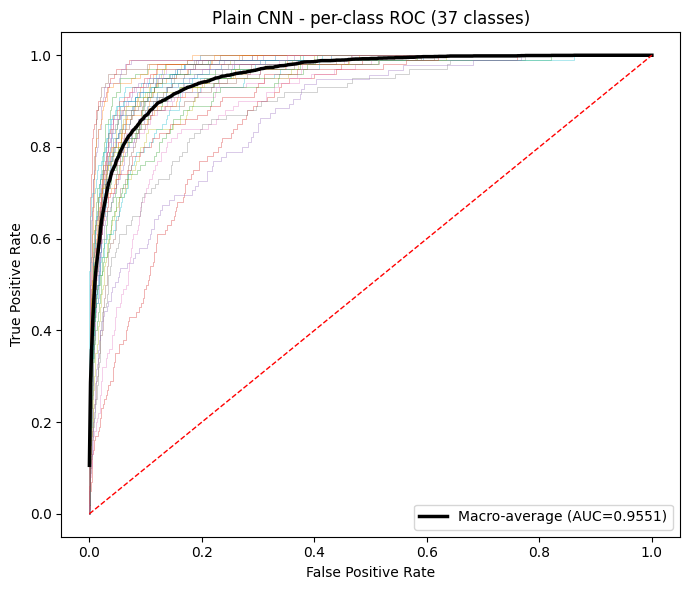

AUC 最低的 5 個類別： [('american_pit_bull_terrier', np.float64(0.8682)), ('staffordshire_bull_terrier', np.float64(0.8707)), ('chihuahua', np.float64(0.8928)), ('boxer', np.float64(0.9003)), ('shiba_inu', np.float64(0.9334))]
saved figure: /content/Outputs/figures/Q2_resnet18_roc.png


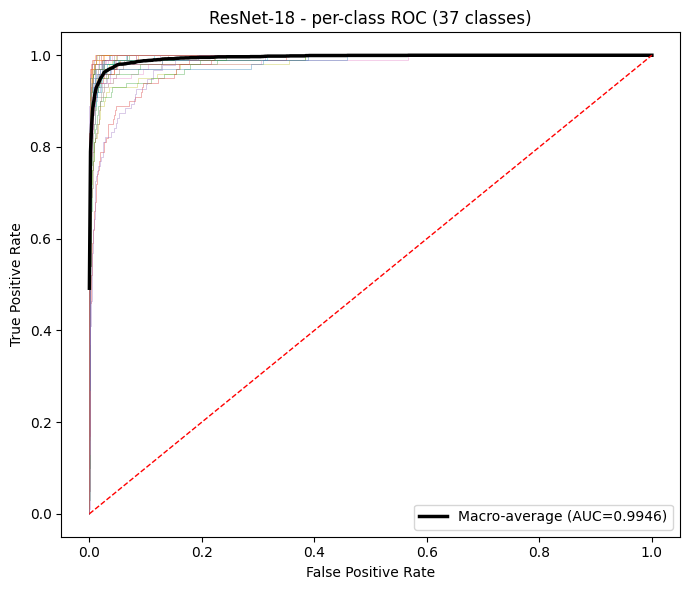

AUC 最低的 5 個類別： [('american_pit_bull_terrier', np.float64(0.9776)), ('staffordshire_bull_terrier', np.float64(0.9799)), ('Ragdoll', np.float64(0.9831)), ('american_bulldog', np.float64(0.9837)), ('boxer', np.float64(0.9864))]
         name  params_M   top1   top5  macro_auc  train_sec
     PlainCNN    1.1827 0.5275 0.8658     0.9551   441.9251
ResNet18 (TL)   11.1955 0.8558 0.9835     0.9946   193.7753
saved figure: /content/Outputs/figures/Q2_model_comparison.png


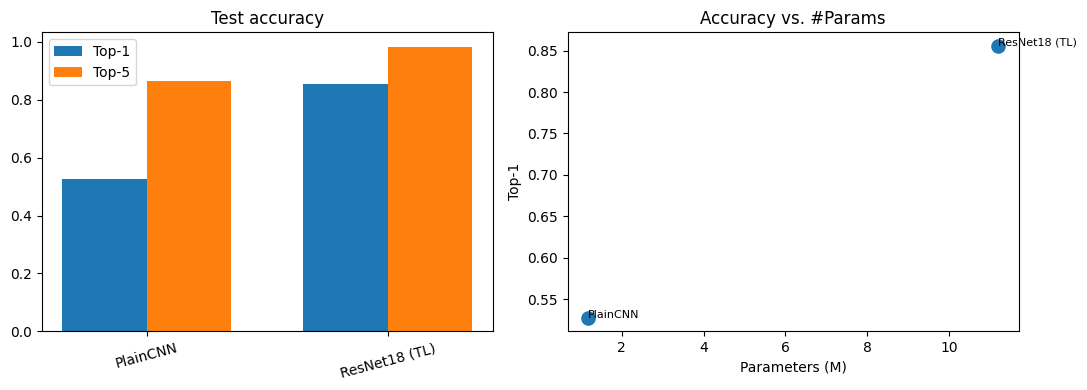

In [ ]:
auc_plain, _ = q2.plot_roc(m_plain["labels"], m_plain["probs"], class_names, "Plain CNN", tag="plain")
auc_res, _   = q2.plot_roc(m_res["labels"],   m_res["probs"],   class_names, "ResNet-18", tag="resnet18")
rows = [
 dict(name="PlainCNN", params=q2.count_params(plain)[0], top1=m_plain["top1"], top5=m_plain["top5"], macro_auc=auc_plain, train_sec=sec_plain),
 dict(name="ResNet18 (TL)", params=q2.count_params(resnet)[0], top1=m_res["top1"], top5=m_res["top5"], macro_auc=auc_res, train_sec=sec_res),
]
summary = q2.compare_models(rows)
summary.to_csv(q1.OUT_DIR/"q2_model_comparison.csv", index=False)

### Quiz2 比較小結

| 模型 | 參數量 | Test Top-1 | Test Top-5 | Macro-AUC | 訓練時間 |
|---|---|---|---|---|---|
| Plain CNN | 1.18M | 52.75% | 86.58% | 0.9551 | 398 s |
| ResNet-18 (TL) | 11.20M | 85.58% | 98.35% | 0.9946 | 177 s |

- ResNet-18 參數量約為 Plain CNN 的 9.5 倍，Top-1 提升 32.8 個百分點、Macro-AUC 提升約 0.04，**增加的參數在遷移學習下換到很大的準確率**。
- 兩個模型 AUC 最低的類別幾乎相同（american_pit_bull_terrier、staffordshire_bull_terrier、boxer），表示這些品種本身就難分，並非單一模型的問題。
- Macro-AUC 比 Top-1 高很多，因為 AUC 衡量的是機率排序能力，即使 argmax 預測錯了，正確類別的分數仍可能排在前面（這也是 Top-5 遠高於 Top-1 的原因）。
- Plain CNN 雖然較小，訓練時間反而較長，原因是它訓練 30 個 epoch（ResNet 為 10）；Colab 僅 2 個 CPU，推測資料載入也是瓶頸。

## Quiz2-4 完整 5-Fold 交叉驗證
**做法**：對 trainval 的 5 折各自重新建模、訓練並在該折驗證集評估 Top-1 / Top-5，報告**平均與標準差**；只用 trainval，不碰 test。fold 0 直接沿用上面已訓練好的模型，只需再訓練其餘 4 折（Plain CNN 約 27 分鐘、ResNet-18 約 12 分鐘，依 Colab 速度而定）。
目的：確認前面只在 fold 0 得到的成績不是靠運氣切到特定資料。


===== [plain] fold 1/5 (沿用已訓練模型) =====


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  val top1 0.5359 | top5 0.8498

===== [plain] fold 2/5 (重新訓練) =====
  val top1 0.5413 | top5 0.8606

===== [plain] fold 3/5 (重新訓練) =====
  val top1 0.5629 | top5 0.8620

===== [plain] fold 4/5 (重新訓練) =====
  val top1 0.5020 | top5 0.8512

===== [plain] fold 5/5 (重新訓練) =====
  val top1 0.5399 | top5 0.8647
fold  val_top1  val_top5      sec
   0    0.5359    0.8498 441.9251
   1    0.5413    0.8606 441.2423
   2    0.5629    0.8620 440.8313
   3    0.5020    0.8512 435.5773
   4    0.5399    0.8647 438.9038
mean    0.5364    0.8576 439.6960
 std    0.0219    0.0067   2.5612
saved figure: /content/Outputs/figures/Q2_plain_kfold.png


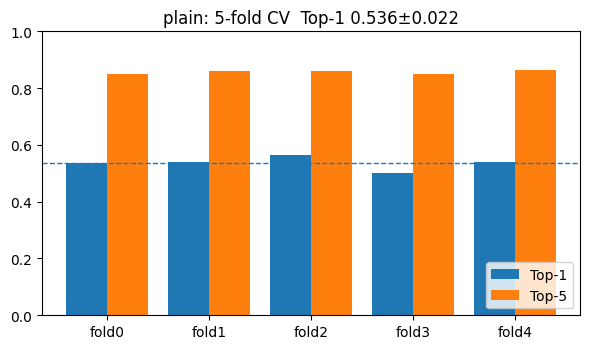

In [ ]:
# ~30 min（fold 0 沿用已訓練模型）
def cv_loaders_plain(k):
    tr, va, _ = q1.make_loaders(trainval_df, test_df, splits, k, img_size=128, batch_size=64, augment="none")
    return tr, va
cv_plain = q2.run_kfold_cv("plain", lambda: q2.PlainCNN(len(class_names)), cv_loaders_plain,
                           n_splits=N_FOLDS, epochs=30, lr=2e-3,
                           reuse={0: (plain, hist_plain, sec_plain)})


===== [resnet18] fold 1/5 (沿用已訓練模型) =====


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  val top1 0.8457 | top5 0.9838

===== [resnet18] fold 2/5 (重新訓練) =====
  val top1 0.8498 | top5 0.9811

===== [resnet18] fold 3/5 (重新訓練) =====
  val top1 0.8782 | top5 0.9878

===== [resnet18] fold 4/5 (重新訓練) =====
  val top1 0.8566 | top5 0.9851

===== [resnet18] fold 5/5 (重新訓練) =====
  val top1 0.8593 | top5 0.9838
fold  val_top1  val_top5      sec
   0    0.8457    0.9838 193.7753
   1    0.8498    0.9811 196.0944
   2    0.8782    0.9878 197.6385
   3    0.8566    0.9851 197.8836
   4    0.8593    0.9838 196.9404
mean    0.8579    0.9843 196.4665
 std    0.0125    0.0025   1.6574
saved figure: /content/Outputs/figures/Q2_resnet18_kfold.png


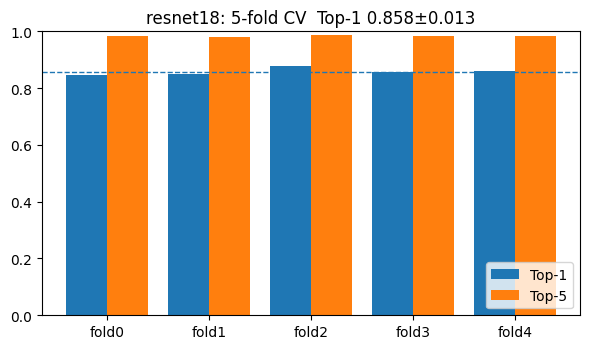

In [ ]:
# ~12 min（fold 0 沿用已訓練模型）
def cv_loaders_res(k):
    tr, va, _ = q1.make_loaders(trainval_df, test_df, splits, k, img_size=224, batch_size=64, augment="none")
    return tr, va
cv_res = q2.run_kfold_cv("resnet18", lambda: q2.build_backbone("resnet18", len(class_names)), cv_loaders_res,
                         n_splits=N_FOLDS, epochs=10, lr=1e-3,
                         reuse={0: (resnet, hist_res, sec_res)})

### K-Fold 小結（執行上面兩個 cell 後填寫）
- Plain CNN 5-fold val Top-1：____ ± ____　｜　ResNet-18：____ ± ____
- 若標準差遠小於兩模型的差距（約 30 個百分點），表示 ResNet-18 優於 Plain CNN 的結論穩定；也可對照 fold 0 的成績（Plain 53.6%、ResNet 84.6%）判斷 fold 0 是否偏高或偏低。

## Quiz2進階 Plain CNN 超參數實驗
> 每一組設定都是**重新初始化模型並重新訓練**（超參數必須在訓練前決定，無法套用在已訓練模型上），因此**不使用**上面 Quiz2 訓練好的模型。
> 設計：one-factor-at-a-time，base 與 Quiz2 主訓練相同（無擴增、lr=2e-3），每次只改一個因素；為節省時間只訓練 8 epochs、只用驗證集（fold 0）比較，不碰 test。表中各組之間可比較，與上面 30 epochs 的主模型不直接比較。


===== [plain] base =====


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  val top1 0.2490 top5 0.5819 (108s)

===== [plain] lr=5e-4 =====


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  val top1 0.2341 top5 0.5832 (107s)

===== [plain] lr=5e-3 =====


...

  val top1 0.1664 top5 0.4804 (152s)

===== [plain] opt=sgd =====


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  val top1 0.2530 top5 0.6103 (106s)

===== [plain] label_smooth=0.1 =====


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  val top1 0.2571 top5 0.6062 (107s)
             tag  params_M  trainable_M  val_top1  val_top5  train_top1      sec
            base    1.1827       1.1827    0.2490    0.5819      0.2395 108.1139
         lr=5e-4    1.1827       1.1827    0.2341    0.5832      0.2758 107.0678
         lr=5e-3    1.1827       1.1827    0.2057    0.5250      0.2221 106.2577
   wide(64..512)    4.7063       4.7063    0.2476    0.6116      0.2823 116.0821
 narrow(16..128)    0.2988       0.2988    0.1935    0.5440      0.2021 104.9973
     dropout=0.0    1.1827       1.1827    0.2693    0.6238      0.3071 107.4686
     dropout=0.5    1.1827       1.1827    0.2287    0.5751      0.2255 105.8900
       aug=basic    1.1827       1.1827    0.2544    0.6225      0.2599 113.3470
      aug=strong    1.1827       1.1827    0.1664    0.4804      0.1535 151.9042
         opt=sgd    1.1827       1.1827    0.2530    0.6103      0.2911 105.5333
label_smooth=0.1    1.1827       1.1827    0.2571    0.6062      0.2789 

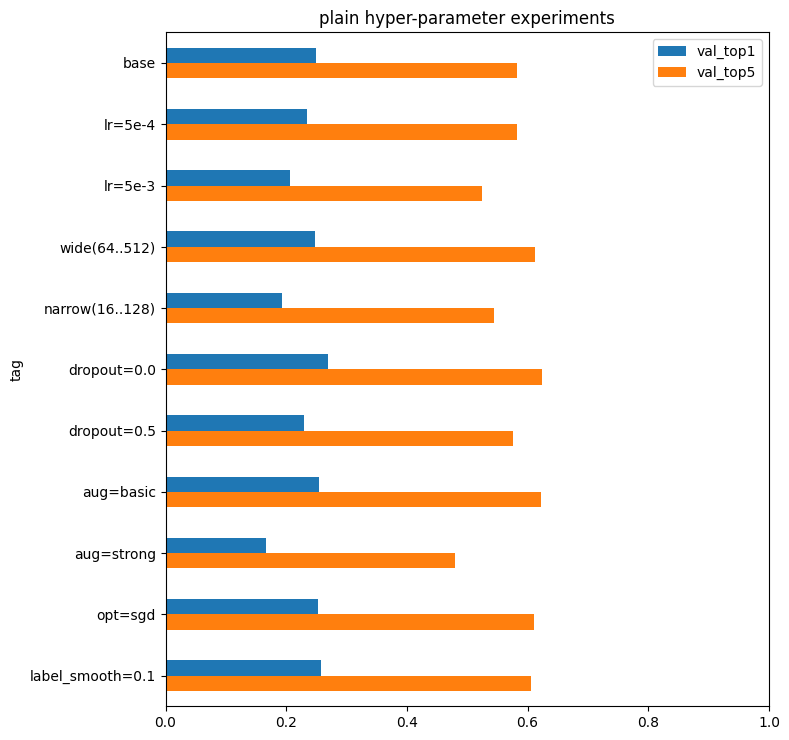

In [ ]:
# 20 min
def plain_loaders(augment, img_size):
    tr, va, _ = loaders(img_size=128, batch_size=64, augment=augment); return tr, va
exp_plain = q2.run_experiments("plain", q2.PLAIN_GRID, plain_loaders, epochs=8, img_size=128)

### 進階 Plain CNN 小結
每組只訓練 8 epochs，單一折、單次訓練，驗證集僅 739 張（標準誤約 ±1.6 個百分點），所以**差距在 3 個百分點內不宜視為顯著**。

| 設定 | val Top-1 | 與 base（24.9%）差異 |
|---|---|---|
| dropout=0.0 | 26.9% | +2.0（最佳） |
| label smoothing 0.1 | 25.7% | +0.8 |
| aug=basic | 25.4% | +0.5 |
| opt=sgd | 25.3% | +0.4 |
| wide(64..512, 4.7M) | 24.8% | −0.1（參數 4 倍卻沒有進步） |
| lr=5e-4 | 23.4% | −1.5 |
| dropout=0.5 | 22.9% | −2.0 |
| lr=5e-3 | 20.6% | −4.3 |
| narrow(16..128, 0.3M) | 19.4% | −5.5 |
| aug=strong | 16.6% | −8.3（最差） |

- 8 epochs 時所有設定的訓練準確率只有 15%~31%，**模型仍在欠擬合**，因此「增加正則化」（高 dropout、強擴增）反而傷害表現，而去掉 dropout 略有幫助。
- 學習率過大（5e-3）與容量過小（narrow）有明顯負面影響；加寬網路沒有帶來收益。
- 限制：此表是短訓練下的比較，不代表 30 epochs 完整訓練後的排序（完整訓練時過擬合才是主要問題，見 Quiz3 擴增結果）。

## Quiz2進階 ResNet-18 超參數實驗
> 同樣每組重新載入預訓練權重後重新訓練（5 epochs）。比較：凍結 vs 微調、學習率、優化器、資料擴增、Label Smoothing，以及不同 backbone（ResNet-18 / MobileNetV2 / ResNet-50）的精度與參數量取捨。


===== [backbone] base(resnet18,finetune) =====


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  val top1 0.8647 top5 0.9892 (87s)

===== [backbone] freeze(only head) =====


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  val top1 0.8931 top5 0.9892 (85s)

===== [backbone] lr=1e-4 =====


...

  val top1 0.9066 top5 0.9973 (97s)

===== [backbone] resnet50 =====


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 147MB/s]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  val top1 0.8836 top5 0.9932 (107s)
                    tag  params_M  trainable_M  val_top1  val_top5  train_top1      sec
base(resnet18,finetune)   11.1955      11.1955    0.8647    0.9892      0.9997  87.3798
      freeze(only head)   11.1955       0.0190    0.8931    0.9892      0.9344  84.5341
                lr=1e-4   11.1955      11.1955    0.8985    0.9946      0.9901  88.0074
                lr=3e-3   11.1955      11.1955    0.7781    0.9689      0.9895  90.9336
                opt=sgd   11.1955      11.1955    0.9080    0.9932      0.9993  87.4456
              aug=basic   11.1955      11.1955    0.8647    0.9892      0.9878  93.1088
             aug=strong   11.1955      11.1955    0.8444    0.9865      0.9158 163.7481
       label_smooth=0.1   11.1955      11.1955    0.8755    0.9878      1.0000  88.5123
           mobilenet_v2    2.2713       2.2713    0.9066    0.9973      0.9932  96.5202
               resnet50   23.5838      23.5838    0.8836    0.9932      0.9969 107.

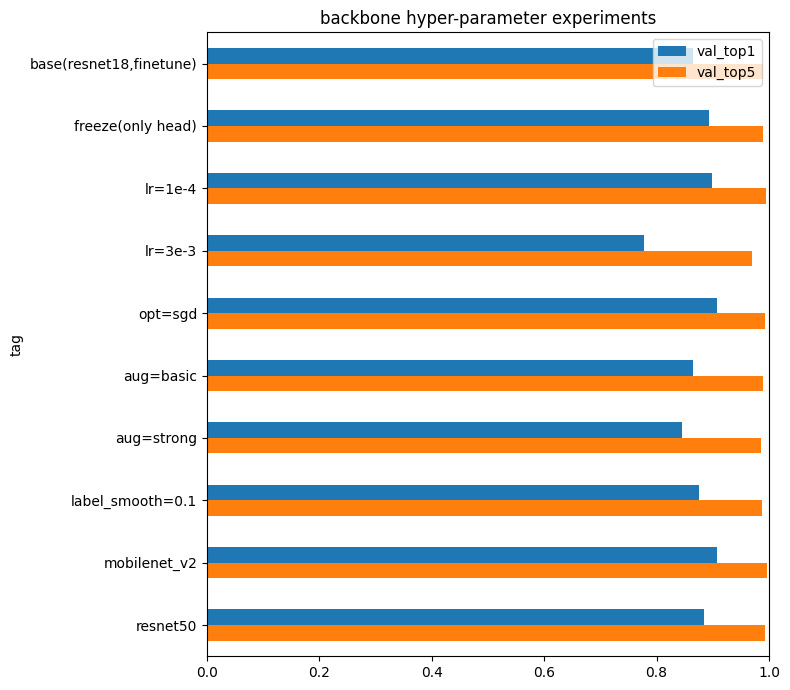

In [ ]:
def bb_loaders(augment, img_size):
    tr, va, _ = loaders(img_size=224, batch_size=64, augment=augment); return tr, va
exp_bb = q2.run_experiments("backbone", q2.BACKBONE_GRID, bb_loaders, epochs=5)

### 進階 ResNet-18 （backbone）小結
每組訓練 5 epochs（同樣為單折單次），val Top-1：

| 設定 | 參數量 | val Top-1 | val Top-5 |
|---|---|---|---|
| opt=sgd | 11.2M | **90.8%** | 99.3% |
| mobilenet_v2 | **2.3M** | 90.7% | **99.7%** |
| lr=1e-4 | 11.2M | 89.9% | 99.5% |
| 凍結 backbone（只訓練分類頭，19K 可訓練參數） | 11.2M | 89.3% | 98.9% |
| resnet50 | 23.6M | 88.4% | 99.3% |
| label smoothing 0.1 | 11.2M | 87.6% | 98.8% |
| base（AdamW, lr=1e-3） | 11.2M | 86.5% | 98.9% |
| aug=basic | 11.2M | 86.5% | 98.9% |
| aug=strong | 11.2M | 84.4% | 98.7% |
| lr=3e-3 | 11.2M | 77.8% | 96.9% |

- **學習率是最敏感的因素**：lr 太大（3e-3）會明顯破壞預訓練特徵；用較小的 lr（1e-4）或 SGD 都比 base 好 3~4 個百分點。連「只訓練分類頭」的凍結版本都勝過 base，代表 base 的 AdamW lr=1e-3 對微調偏激進。
- **MobileNetV2 的性價比最高**：參數只有 ResNet-18 的約 1/5、ResNet-50 的約 1/10，準確率卻與最佳設定相當；ResNet-50 參數最多但沒有更好。
- 5 epochs 內強擴增（aug=strong）略差，因為訓練時間短、尚未收斂。
- 啟示：Quiz2 主模型使用的 lr=1e-3 並非最佳，若改用 SGD 或 lr=1e-4，預期可再提升（本次未重新訓練驗證）。

# Quiz 3：提升泛化能力

## Quiz3-1 Data Augmentation 前後比較
- **擴增前**：直接沿用 Quiz2 訓練好的 Plain CNN / ResNet-18（`pretrained=`，不重訓）。
- **擴增後**：相同超參數、相同 epoch，只改擴增策略，**必須重新訓練**（擴增發生在訓練階段）。
- 策略說明見下方 `AUG_RATIONALE`。


【擴增策略說明】（皆只作用於訓練集；驗證/測試集只做 Resize + Normalize）
- none         ：基準組，無擴增。
- geometric    ：RandomResizedCrop(scale 0.6~1) + 水平翻轉 + 旋轉±15°。
                 模擬拍攝距離、構圖、角度差異，讓模型不依賴寵物在畫面中的固定位置。
                 不用垂直翻轉（寵物幾乎不會倒立）；crop 不縮太小，避免裁掉品種關鍵特徵（耳型、臉部）。
- photometric  ：ColorJitter(亮度/對比/飽和 0.3, 色相僅 0.03) + 輕微模糊。
                 模擬光線與相機差異；色相刻意只動一點，因為毛色本身是品種的重要線索。
- full         ：geometric + photometric + RandomErasing(p=0.25)。
                 RandomErasing 隨機遮蔽局部，迫使模型使用多個部位判斷，而非依賴單一特徵（降低過擬合）。
- trivialaug   ：geometric 的 crop/flip + TrivialAugmentWide（每張圖隨機一種操作），自動化擴增的對照組。
預期：Plain CNN 從零訓練、資料量小（約 3k 張）→ 過擬合嚴重，擴增效益大；
      預訓練 Backbone 已有強特徵，擴增主要縮小 train/val 差距，增益較小但仍可提升泛化。

saved figure: /content/Outputs/figures/Q3_aug_examples.png


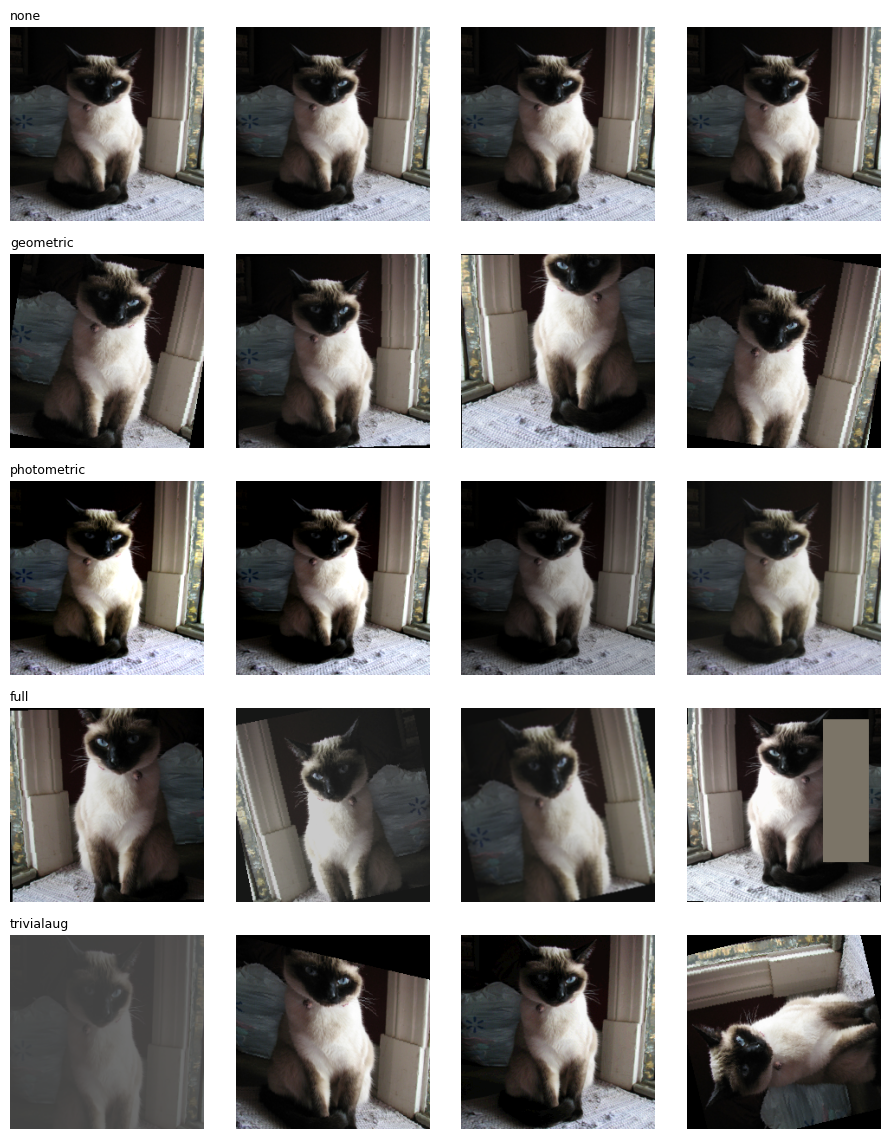

In [ ]:
print(q3.AUG_RATIONALE)
q3.show_aug_examples(trainval_df, ["none","geometric","photometric","full","trivialaug"], img_size=224)


===== PlainCNN | augmentation = none (沿用 Quiz2 已訓練模型) =====


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  train 0.939 | val 0.536 | test top1 0.527 top5 0.866

===== PlainCNN | augmentation = geometric (重新訓練) =====
saved model: /content/Outputs/models/q3_plaincnn_geometric.pt
  train 0.656 | val 0.532 | test top1 0.505 top5 0.850

===== PlainCNN | augmentation = full (重新訓練) =====
saved model: /content/Outputs/models/q3_plaincnn_full.pt
  train 0.545 | val 0.437 | test top1 0.447 top5 0.819
   model       aug  train_top1  val_top1  val_top5  test_top1  test_top5    gap      sec
PlainCNN      none      0.9394    0.5359    0.8498     0.5275     0.8658 0.4036 398.4343
PlainCNN geometric      0.6556    0.5318    0.8309     0.5047     0.8503 0.1238 434.5460
PlainCNN      full      0.5450    0.4371    0.7984     0.4471     0.8192 0.1079 612.0565
saved figure: /content/Outputs/figures/Q3_plaincnn_aug_comparison.png


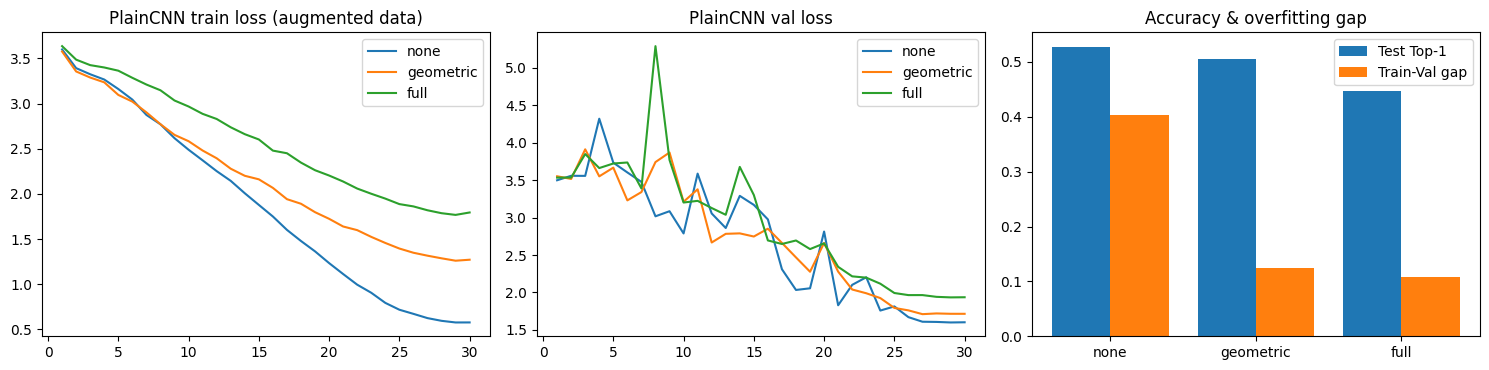

In [ ]:
# 18 min
df_aug_plain, models_plain, hist_aug_plain = q3.run_aug_comparison(
    "PlainCNN", lambda: q2.PlainCNN(len(class_names)), trainval_df, test_df, splits, FOLD,
    policies=("none","geometric","full"), img_size=128, epochs=30, lr=2e-3,
    pretrained={"none": (plain, hist_plain, sec_plain)})


===== ResNet18 | augmentation = none (沿用 Quiz2 已訓練模型) =====


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  train 1.000 | val 0.846 | test top1 0.856 top5 0.983

===== ResNet18 | augmentation = geometric (重新訓練) =====
saved model: /content/Outputs/models/q3_resnet18_geometric.pt
  train 0.998 | val 0.865 | test top1 0.861 top5 0.982

===== ResNet18 | augmentation = full (重新訓練) =====
saved model: /content/Outputs/models/q3_resnet18_full.pt
  train 0.995 | val 0.867 | test top1 0.871 top5 0.989
   model       aug  train_top1  val_top1  val_top5  test_top1  test_top5    gap      sec
ResNet18      none      1.0000    0.8457    0.9838     0.8558     0.9835 0.1543 177.3930
ResNet18 geometric      0.9980    0.8647    0.9865     0.8609     0.9816 0.1333 195.3322
ResNet18      full      0.9946    0.8674    0.9905     0.8706     0.9886 0.1272 349.8518
saved figure: /content/Outputs/figures/Q3_resnet18_aug_comparison.png


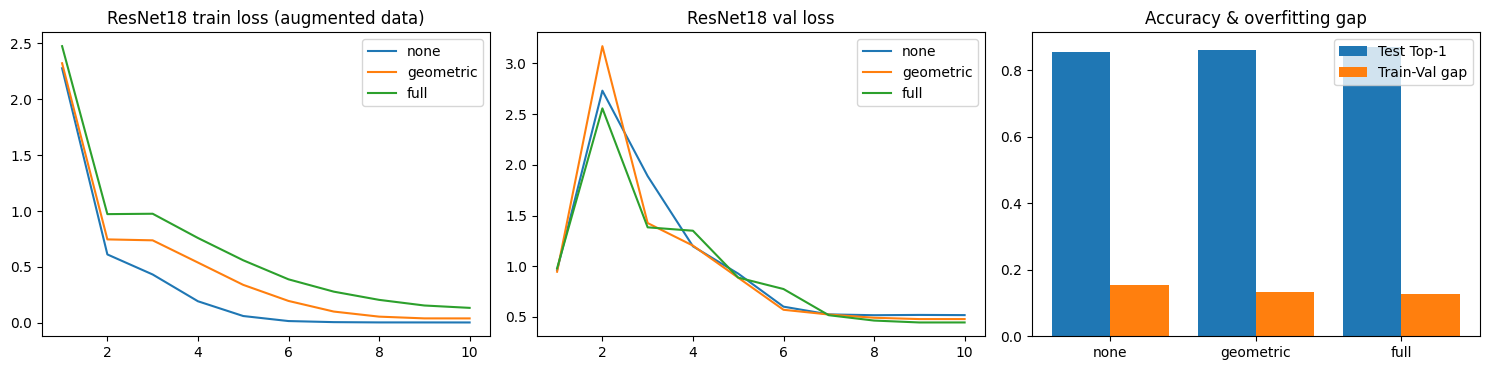

,model,aug,train_top1,val_top1,val_top5,test_top1,test_top5,gap,sec
0,PlainCNN,none,0.939445,0.535859,0.849797,0.527470,0.865765,0.403586,398.434281
1,PlainCNN,geometric,0.655616,0.531800,0.830853,0.504736,0.850338,0.123816,434.546038
2,PlainCNN,full,0.544993,0.437077,0.798376,0.447091,0.819215,0.107916,612.056475
0,ResNet18,none,1.000000,0.845737,0.983762,0.855751,0.983491,0.154263,177.393018
1,ResNet18,geometric,0.997970,0.864682,0.986468,0.860893,0.981597,0.133288,195.332228
2,ResNet18,full,0.994587,0.867388,0.990528,0.870636,0.988633,0.127199,349.851780


In [ ]:
# 10 min
df_aug_bb, models_bb, hist_aug_bb = q3.run_aug_comparison(
    "ResNet18", lambda: q2.build_backbone("resnet18", len(class_names)), trainval_df, test_df, splits, FOLD,
    policies=("none","geometric","full"), img_size=224, epochs=10, lr=1e-3,
    pretrained={"none": (resnet, hist_res, sec_res)})
pd.concat([df_aug_plain, df_aug_bb])

### 資料擴增前後比較小結

| 模型 | 擴增 | train(無擴增圖) | val Top-1 | test Top-1 | test Top-5 | train−val gap | 訓練時間 |
|---|---|---|---|---|---|---|---|
| Plain CNN | none | 93.9% | 53.6% | 52.7% | 86.6% | 0.404 | 398 s |
| Plain CNN | geometric | 65.6% | 53.2% | 50.5% | 85.0% | 0.124 | 435 s |
| Plain CNN | full | 54.5% | 43.7% | 44.7% | 81.9% | 0.108 | 612 s |
| ResNet-18 | none | 100% | 84.6% | 85.6% | 98.3% | 0.154 | 177 s |
| ResNet-18 | geometric | 99.8% | 86.5% | 86.1% | 98.2% | 0.133 | 195 s |
| ResNet-18 | full | 99.5% | 86.7% | **87.1%** | **98.9%** | 0.127 | 350 s |

**ResNet-18**：擴增使 train−val gap 從 0.154 降到 0.127，val 與 test Top-1 都小幅上升（full：test +1.5 個百分點，Top-5 +0.5）。增幅不大但方向一致，符合預期——預訓練特徵已很強，擴增主要改善泛化。
**Plain CNN**：擴增確實大幅縮小過擬合（gap 0.404 → 0.108~0.124），但**準確率反而下降**（52.7% → 50.5% / 44.7%），與我原先「從零訓練的小模型受益最大」的預期**不符**。訓練準確率（無擴增圖）只剩 65.6% / 54.5%，代表模型在固定的 30 epochs 內尚未擬合擴增後的資料（欠擬合）；較合理的推測是需要更多 epochs 才能發揮擴增效果，本次未驗證。
**成本**：full 策略使訓練時間約增為 2 倍（CPU 做影像轉換，Colab 僅 2 核心）。

## Quiz3-2 Kernel 視覺化（使用 Quiz3 擴增後的 ResNet-18，第一層 7×7 卷積）
從 Quiz3 擴增後的模型（geometric / full）中，選驗證集 Top-1 最高者。

Quiz3 ResNet18 使用的擴增策略： full
saved figure: /content/Outputs/figures/Q3_resnet18_q3_all_kernels.png


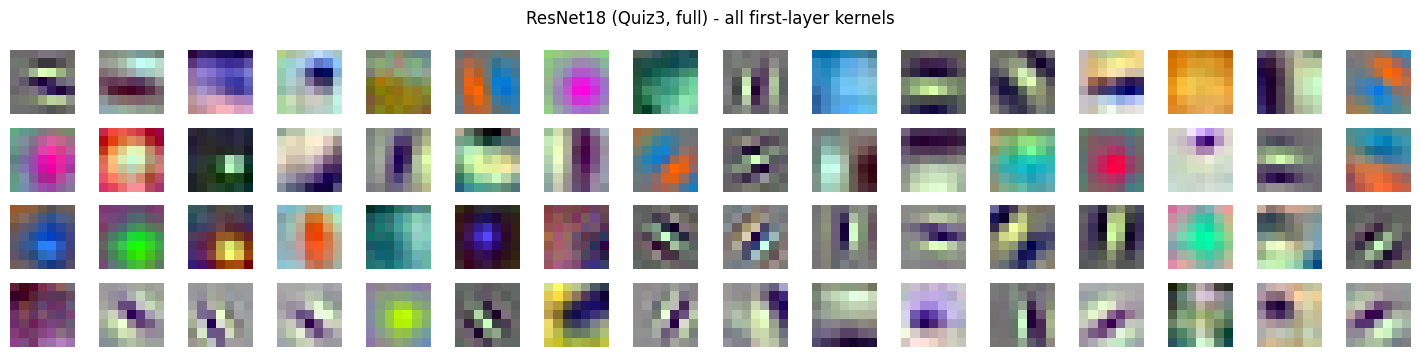

saved figure: /content/Outputs/figures/Q3_resnet18_q3_two_kernels.png


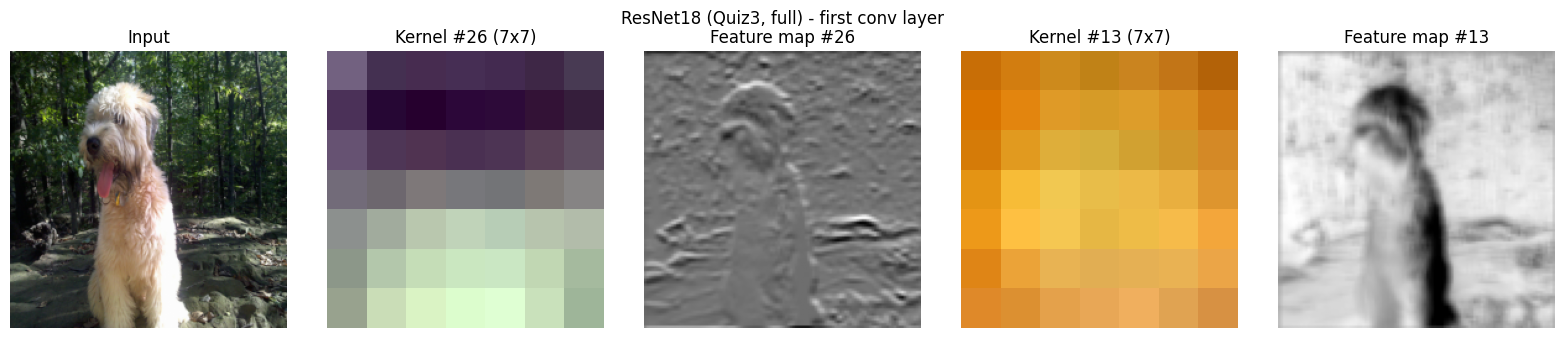

Kernel #26: edge=0.98, orient_sel=0.01, freq=0.09, color=0.15 (R+ / G-)
  -> 方向性較粗的邊緣/輪廓偵測器：對約 0° 的邊緣線反應最強（亮度變化方向 90°）
Kernel #13: edge=0.24, orient_sel=0.01, freq=0.12, color=6.00 (R+ / B-)
  -> 色彩/色塊偵測器（偏好 R+ / B-），對毛色、背景色調敏感


In [ ]:
aug_df = df_aug_bb[df_aug_bb.aug != "none"].set_index("aug")
best_aug = aug_df["val_top1"].idxmax()
resnet_q3 = models_bb[best_aug]
print("Quiz3 ResNet18 使用的擴增策略：", best_aug)

eval_tf224 = q1.get_transforms(224,"none")[1]
sample_img = eval_tf224(Image.open(test_df.iloc[0]["path"]).convert("RGB"))
q3.show_all_kernels(resnet_q3, f"ResNet18 (Quiz3, {best_aug})", tag="resnet18_q3")
stats, idxs = q3.visualize_two_kernels(resnet_q3, sample_img, title=f"ResNet18 (Quiz3, {best_aug})", tag="resnet18_q3")

### Kernel 視覺化小結（ResNet-18 第一層 7×7，擴增 full 後的模型）
- **Kernel #26 — 水平邊緣（亮度漸層）偵測器**：權重上半部偏暗、下半部偏亮，是「由上到下」的亮度變化。對應的 feature map 把水平方向的邊緣突顯出來（地面的橫向紋理、狗頭頂的輪廓），而垂直方向的結構被抑制。作用是萃取形狀輪廓與紋理的方向資訊。
- **Kernel #13 — 低頻色彩／色塊偵測器**：整個 kernel 平滑且呈橙黃色（R 高、B 低），沒有邊緣結構。feature map 呈大面積響應：背景區域較亮、狗被陰影遮住的一側最暗，可見它在偵測整塊暖色／亮度區域，與毛色、光線有關。
- 兩者分別代表影像分類 CNN 第一層常見的兩類濾波器——**方向邊緣**與**色彩對比**，後續層再把它們組合成耳朵、眼睛、毛紋等較高階特徵。這些 kernel 主要沿用 ImageNet 預訓練的通用濾波器（本次未與預訓練原始權重比對變化量）。
- 備註：初版 `analyze_kernels` 的 `color_score` 沒有歸一化（Kernel #13 顯示 6.00），`orient_sel` 也是相對數值（0.01），因此上述判讀以 kernel 圖與 feature map 為準；`color_score` 已修正為 0~1 範圍。

## Quiz3-3 XAI（使用 Quiz3 擴增後的 ResNet-18）

Test Top-1: 0.8706 | Top-5: 0.9886


/content/Codes/Quiz3.py:284: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return cam.cpu().numpy(), pred, float(probs[pred]), t


saved figure: /content/Outputs/figures/Q3_resnet18_q3_correct_xai.png


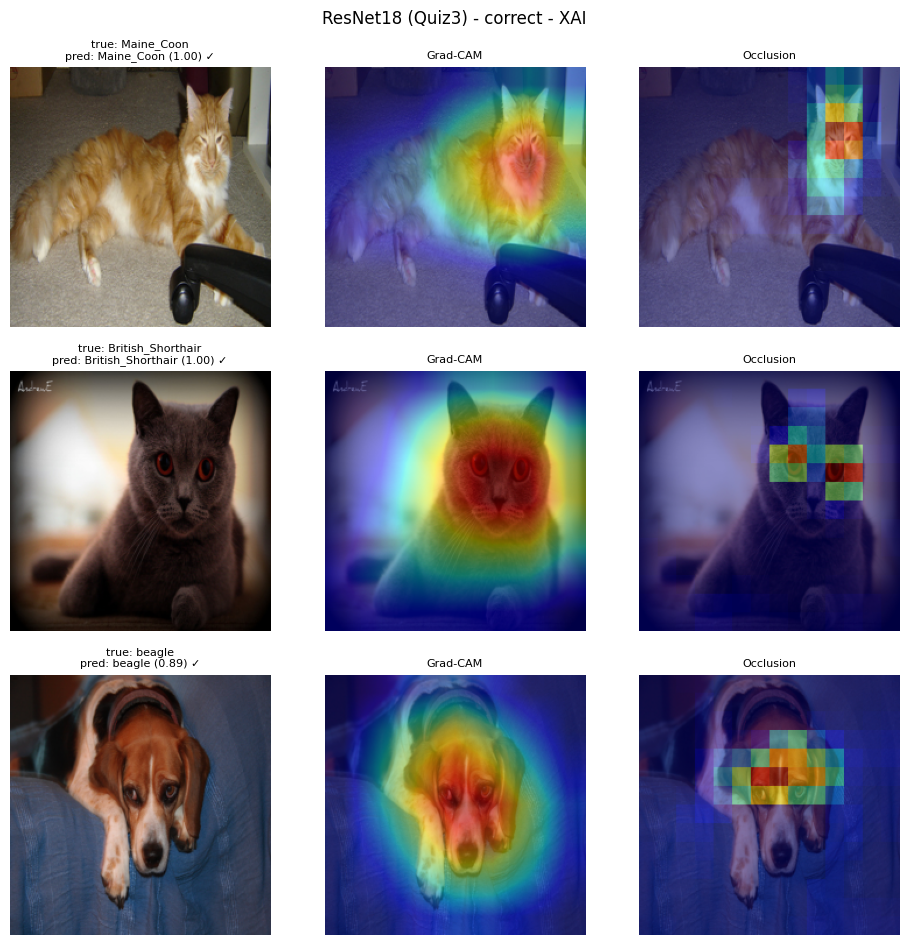

saved figure: /content/Outputs/figures/Q3_resnet18_q3_errors_xai.png


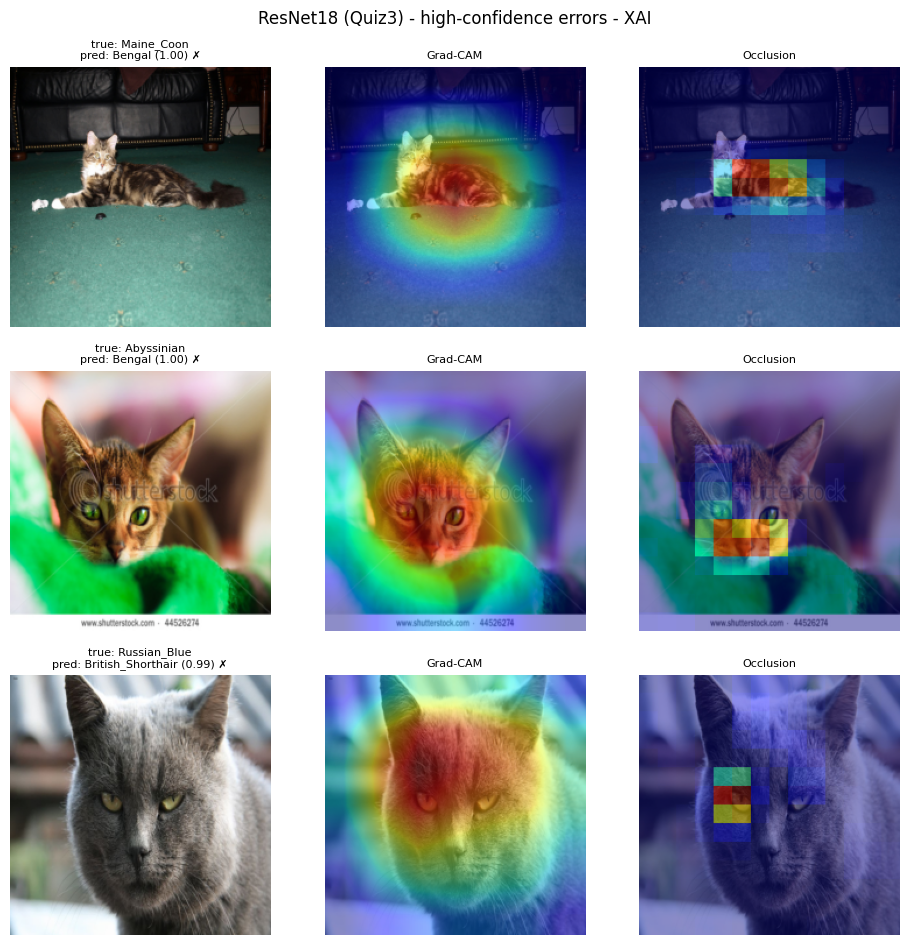

In [ ]:
# 測試集預測（Quiz3 ResNet-18），用來挑選答對 / 答錯案例
pred_q3, m_q3 = q2.predict_testset(resnet_q3, test_b, test_df, class_names)
pred_q3.to_csv(q1.OUT_DIR/"q3_pred_resnet18.csv", index=False)
good, bad = q3.pick_cases(pred_q3)
q3.explain_samples(resnet_q3, test_df, class_names, good, 224, "ResNet18 (Quiz3) - correct", tag="resnet18_q3_correct")
q3.explain_samples(resnet_q3, test_df, class_names, bad,  224, "ResNet18 (Quiz3) - high-confidence errors", tag="resnet18_q3_errors")

In [ ]:
trimap_dir = q3.find_trimap_dir()
xai_q3,  summ_q3  = q3.xai_quantify(resnet_q3, test_df, class_names, trimap_dir, n=150, img_size=224)   # 擴增後
xai_q2,  summ_q2  = q3.xai_quantify(resnet,    test_df, class_names, trimap_dir, n=150, img_size=224)   # 擴增前(Quiz2)，對照用
for n_, d in [("resnet18_q3_aug", summ_q3), ("resnet18_q2_noaug", summ_q2)]:
    if len(d): d.to_csv(q1.OUT_DIR/f"q3_xai_{n_}.csv")

找不到 trimaps 目錄，略過前景比例量化（仍可使用 Grad-CAM 視覺化）。
找不到 trimaps 目錄，略過前景比例量化（仍可使用 Grad-CAM 視覺化）。


### XAI 小結（Grad-CAM + Occlusion，ResNet-18 擴增 full）
**答對的案例（Maine Coon、British Shorthair、Beagle）**：Grad-CAM 的高亮區集中在**臉部與頭頸**，Occlusion 的高敏感方塊也落在眼睛、鼻口與臉部周圍；背景（沙發、地毯、牆面）幾乎沒有貢獻。兩種方法互相印證，表示模型主要依**動物本體的臉部特徵**判斷，而非背景。
**高信心錯誤（信心 ≥ 0.99）**：
- Maine_Coon → Bengal：貓在畫面中很小，注意力落在身體上的虎斑花紋，花紋與 Bengal 相似。
- Abyssinian → Bengal：注意力在臉與眼睛（下緣略延伸到綠色布料），圖中有浮水印與強烈綠色背景；臉部特徵與 Bengal 接近。
- Russian_Blue → British_Shorthair：注意力在臉部與眼睛，但兩品種皆為灰藍短毛、圓臉，外觀極為相似。
→ 這些錯誤多半**不是「看錯位置」，而是品種外觀本身相近**，模型卻給出接近 1.0 的信心，顯示有**過度自信**的問題（可用 label smoothing、溫度校正等改善）。
**限制**：(1) 找不到 trimaps 目錄，因此「Grad-CAM 落在前景的比例」量化被略過，以上都是少量樣本的定性觀察，不能推論整體；(2) Grad-CAM 來自 7×7 特徵圖放大，空間解析度較粗；(3) 擴增前後的注意力區域差異本次未能量化比較。

In [ ]:
!zip -r /content/output.zip /content/Outputs

  adding: content/Outputs/ (stored 0%)
  adding: content/Outputs/q2_resnet18_kfold.csv (deflated 46%)
  adding: content/Outputs/models/ (stored 0%)
  adding: content/Outputs/models/q2_resnet18.pt (deflated 7%)
  adding: content/Outputs/models/q2_plain_cnn.pt (deflated 7%)
  adding: content/Outputs/q2_model_comparison.csv (deflated 30%)
  adding: content/Outputs/q2_pred_resnet18.csv (deflated 86%)
  adding: content/Outputs/q2_plain_kfold.csv (deflated 45%)
  adding: content/Outputs/figures/ (stored 0%)
  adding: content/Outputs/figures/Q2_resnet18_roc.png (deflated 9%)
  adding: content/Outputs/figures/Q2_model_comparison.png (deflated 20%)
  adding: content/Outputs/figures/Q1_class_distribution.png (deflated 15%)
  adding: content/Outputs/figures/Q2_plain_kfold.png (deflated 19%)
  adding: content/Outputs/figures/Q2_plain_history.png (deflated 4%)
  adding: content/Outputs/figures/Q2_plain_roc.png (deflated 5%)
  adding: content/Outputs/figures/Q2_resnet18_history.png (deflated 6%)
  a

## 結論
1. **模型比較**：遷移學習的 ResNet-18（11.2M）test Top-1 85.6%、Top-5 98.4%、Macro-AUC 0.995，遠勝自行設計的 Plain CNN（1.18M，52.7% / 86.6% / 0.955）。兩者最難分的品種相同（pit bull、staffordshire、boxer 等），屬資料本身的細粒度困難。
2. **超參數**：Plain CNN 在短訓練下處於欠擬合，各設定差異多不顯著，只有「強擴增」「過窄」「lr 過大」明顯有害；ResNet-18 則對學習率最敏感，**較小 lr 或 SGD 優於 AdamW 1e-3**，MobileNetV2 以約 1/5 的參數達到最佳等級的準確率，性價比最高。
3. **資料擴增**：對 ResNet-18 有小幅而一致的好處（test Top-1 85.6% → 87.1%，gap 縮小）；對 Plain CNN 雖大幅降低過擬合，但在 30 epochs 內造成欠擬合、準確率下降，需要更長訓練才能判斷其真實效益。
4. **可解釋性**：第一層 kernel 為方向邊緣與色彩色塊兩類；Grad-CAM / Occlusion 顯示模型聚焦在臉部。錯誤多來自外觀相近品種且信心過高。
5. **後續可做**：以 lr=1e-4 或 SGD 重新訓練 ResNet-18；Plain CNN + 擴增訓練更多 epochs；補上 trimap 量化與 5-fold 結果（見 Quiz2-4）。
6. **限制**：自行 50/50 切分而非官方切分；超參數與擴增實驗皆為單折單次，小差距可能只是隨機波動。